# Day 2 — NLP Tasks & Classical Models

## Sentiment Classification, NER, Sequence Labeling, Topic Modeling & Language Modeling

### Learning outcomes
By the end of this session, we should be able to:
1. Distinguish text classification, sentiment analysis, NER, topic modeling, sequence labeling and language modeling.
2. Build a TF-IDF + Logistic Regression sentiment classifier.
3. Evaluate classification using accuracy, precision, recall, F1 and ROC-AUC.
4. Compare Logistic Regression, Naive Bayes and Linear SVM.
5. Inspect model errors rather than relying only on one metric.
6. Use spaCy to extract named entities.
7. Explain BIO sequence labels and the intuition behind CRF-style sequence labeling.
8. Train an LDA topic model, inspect topics and calculate coherence.

---
### Class flow
- **0–20 min:** NLP-task warm-up
- **20–110 min:** IMDB sentiment lab
- **110–140 min:** NER + sequence labeling
- **140–220 min:** LDA topic-modeling lab
- **220–240 min:** Language-modeling intuition + recap
- **Assignment:** Airline customer-feedback analysis


## 0. Setup

Run this installation cell only if the required packages are not already available.

If the spaCy English model is installed for the first time, restart the kernel if required.


In [11]:
# Run these lines only if the packages are not already installed.
# %pip installs packages into the current Jupyter environment.

#%pip install -q pandas numpy matplotlib scikit-learn datasets spacy gensim pyLDAvis nltk
#!py -m spacy download en_core_web_sm

In [12]:
# Import the libraries required for today's exercises
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display longer text so that we can read reviews during error analysis
pd.set_option("display.max_colwidth", 250)


# 1. Warm-up — Identify the NLP task

### Identify the NLP task for each business problem

| Business question | NLP task |
|---|---|
| Is a customer happy, neutral or unhappy? | Sentiment classification |
| Is an email spam or not spam? | Text classification |
| Which people, companies and places are mentioned? | Named Entity Recognition |
| What themes occur across 50,000 documents? | Topic modeling |
| What label belongs to each word/token? | Sequence labeling |
| What word/token is likely to come next? | Language modeling |

### Class activity

Classify each statement as **Positive, Neutral or Negative**:

- “The crew was fantastic.”
- “My flight departs at 7 PM.”
- “You lost my suitcase again!”

### Think about it

**How can a computer learn to do what we just did?**

### Connection with Day 1

**Text → Numerical representation → Machine-learning model → Prediction**


# 2. Lab 1 — Real-world Sentiment Classification with IMDB

We will use the public **Stanford IMDB Large Movie Review Dataset**. It contains 25,000 labeled training reviews and 25,000 labeled test reviews for binary sentiment.

- `0 = negative`
- `1 = positive`

### Where can the same idea be used?

Think of other situations where we receive large amounts of customer text:

- Product reviews
- Customer complaints
- Survey comments
- App-store reviews
- Support-ticket feedback

### Think about preprocessing

Consider these two statements:

- `I like this movie`
- `I do not like this movie`

Should we blindly remove every stopword?

Words such as **not**, **no**, and **never** can completely change sentiment. For this lab, we will therefore use lightweight cleaning and later compare unigrams with bigrams.


## 2.1 Load the IMDB dataset

### Question

**Why should we keep a test set that the model never sees during training?**

Think in terms of:

**Training data → learning**

**Test data → checking performance on unseen examples**


In [13]:
from datasets import load_dataset

# Load the public Stanford IMDB dataset from Hugging Face.
# The first run requires internet access. Later runs normally use the local cache.
imdb = load_dataset("stanfordnlp/imdb")

print(imdb)


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [14]:
# Convert the Hugging Face datasets into pandas DataFrames.
# This makes exploration and error analysis easier.
train_df = imdb["train"].to_pandas()[["text", "label"]]
test_df = imdb["test"].to_pandas()[["text", "label"]]

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)
display(train_df.head())


Training shape: (25000, 2)
Test shape: (25000, 2)


,text,label
0,"I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore bein...",0
1,"""I Am Curious: Yellow"" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, tha...",0
2,If only to avoid making this type of film in the future. This film is interesting as an experiment but tells no cogent story.<br /><br />One might feel virtuous for sitting thru it because it touches on so many IMPORTANT issues but it does so wit...,0
3,"This film was probably inspired by Godard's Masculin, féminin and I urge you to see that film instead.<br /><br />The film has two strong elements and those are, (1) the realistic acting (2) the impressive, undeservedly good, photo. Apart from th...",0
4,"Oh, brother...after hearing about this ridiculous film for umpteen years all I can think of is that old Peggy Lee song..<br /><br />""Is that all there is??"" ...I was just an early teen when this smoked fish hit the U.S. I was too young to get in ...",0


In [15]:
# Check how many positive and negative reviews are present.
# Class balance is important because accuracy can be misleading when one class dominates.
print("Training labels:")
print(train_df["label"].value_counts())

print("\nTraining label proportions:")
print(train_df["label"].value_counts(normalize=True))


Training labels:
label
0    12500
1    12500
Name: count, dtype: int64

Training label proportions:
label
0    0.5
1    0.5
Name: proportion, dtype: float64


## 2.2 Look at the raw text before modeling

Read a few reviews and answer:

1. Does the sentiment label look reasonable?
2. Do we see HTML such as `<br />`?
3. Is punctuation always useless?
4. What could happen if we remove the word **not**?
5. What other noise can you notice?

A useful rule in NLP is:

**Read the text before deciding how to clean the text.**


In [16]:
# Read one negative and one positive review before building the model.
for label_value, label_name in [(0, "NEGATIVE"), (1, "POSITIVE")]:
    example = train_df[train_df["label"] == label_value].iloc[0]
    print("=" * 90)
    print(label_name)
    print(example["text"][:1000])


NEGATIVE
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far bet

## 2.3 Lightweight cleaning

For this sentiment classifier, we will avoid aggressive stemming and lemmatization.

TF-IDF can work very well with fairly raw text, while excessive cleaning can remove useful sentiment clues.

For now, we will only:

1. Remove obvious HTML tags.
2. Remove repeated whitespace.
3. Preserve the actual words used by the reviewer.


In [17]:
def clean_review(text):
    """
    Perform lightweight cleaning while preserving words important for sentiment.
    
    We intentionally DO NOT remove stopwords here because words such as
    'not', 'no' and 'never' may be important.
    """
    text = re.sub(r"<[^>]+>", " ", text)   # Remove HTML tags such as <br />
    text = re.sub(r"\s+", " ", text)      # Replace repeated whitespace with one space
    return text.strip()

train_df["clean_text"] = train_df["text"].apply(clean_review)
test_df["clean_text"] = test_df["text"].apply(clean_review)

display(train_df[["text", "clean_text"]].head(5))


,text,clean_text
0,"I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore bein...","I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore bein..."
1,"""I Am Curious: Yellow"" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, tha...","""I Am Curious: Yellow"" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, tha..."
2,If only to avoid making this type of film in the future. This film is interesting as an experiment but tells no cogent story.<br /><br />One might feel virtuous for sitting thru it because it touches on so many IMPORTANT issues but it does so wit...,If only to avoid making this type of film in the future. This film is interesting as an experiment but tells no cogent story. One might feel virtuous for sitting thru it because it touches on so many IMPORTANT issues but it does so without any di...
3,"This film was probably inspired by Godard's Masculin, féminin and I urge you to see that film instead.<br /><br />The film has two strong elements and those are, (1) the realistic acting (2) the impressive, undeservedly good, photo. Apart from th...","This film was probably inspired by Godard's Masculin, féminin and I urge you to see that film instead. The film has two strong elements and those are, (1) the realistic acting (2) the impressive, undeservedly good, photo. Apart from that, what st..."
4,"Oh, brother...after hearing about this ridiculous film for umpteen years all I can think of is that old Peggy Lee song..<br /><br />""Is that all there is??"" ...I was just an early teen when this smoked fish hit the U.S. I was too young to get in ...","Oh, brother...after hearing about this ridiculous film for umpteen years all I can think of is that old Peggy Lee song.. ""Is that all there is??"" ...I was just an early teen when this smoked fish hit the U.S. I was too young to get in the theater..."


**WORD CLOUDS**

In [18]:
train_df.head()

,text,label,clean_text
0,"I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore bein...",0,"I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore bein..."
1,"""I Am Curious: Yellow"" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, tha...",0,"""I Am Curious: Yellow"" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, tha..."
2,If only to avoid making this type of film in the future. This film is interesting as an experiment but tells no cogent story.<br /><br />One might feel virtuous for sitting thru it because it touches on so many IMPORTANT issues but it does so wit...,0,If only to avoid making this type of film in the future. This film is interesting as an experiment but tells no cogent story. One might feel virtuous for sitting thru it because it touches on so many IMPORTANT issues but it does so without any di...
3,"This film was probably inspired by Godard's Masculin, féminin and I urge you to see that film instead.<br /><br />The film has two strong elements and those are, (1) the realistic acting (2) the impressive, undeservedly good, photo. Apart from th...",0,"This film was probably inspired by Godard's Masculin, féminin and I urge you to see that film instead. The film has two strong elements and those are, (1) the realistic acting (2) the impressive, undeservedly good, photo. Apart from that, what st..."
4,"Oh, brother...after hearing about this ridiculous film for umpteen years all I can think of is that old Peggy Lee song..<br /><br />""Is that all there is??"" ...I was just an early teen when this smoked fish hit the U.S. I was too young to get in ...",0,"Oh, brother...after hearing about this ridiculous film for umpteen years all I can think of is that old Peggy Lee song.. ""Is that all there is??"" ...I was just an early teen when this smoked fish hit the U.S. I was too young to get in the theater..."


In [19]:
%pip install WordCloud

Note: you may need to restart the kernel to use updated packages.


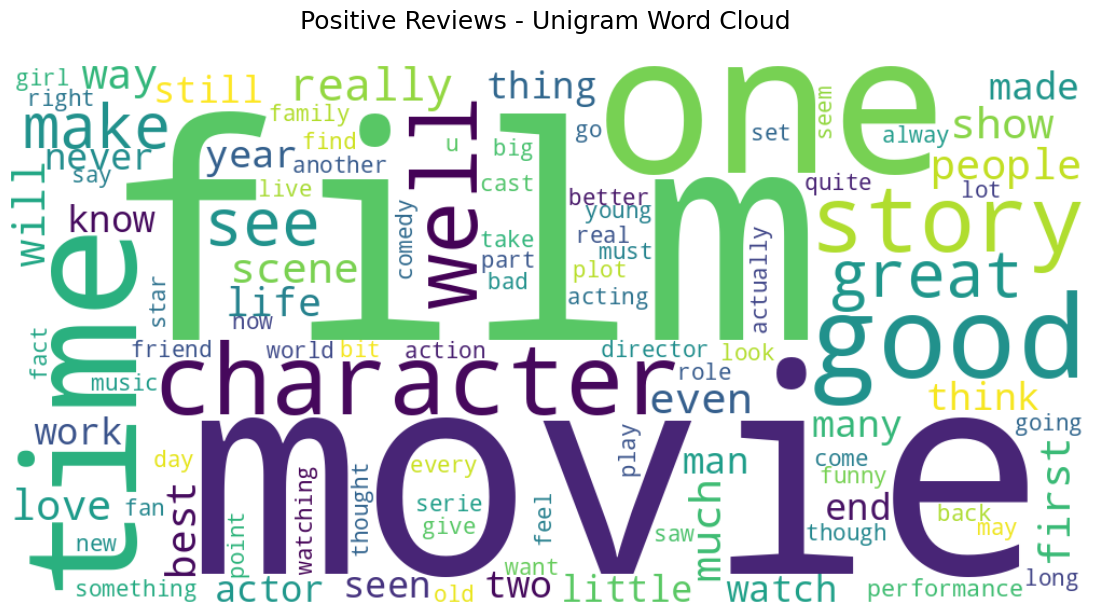

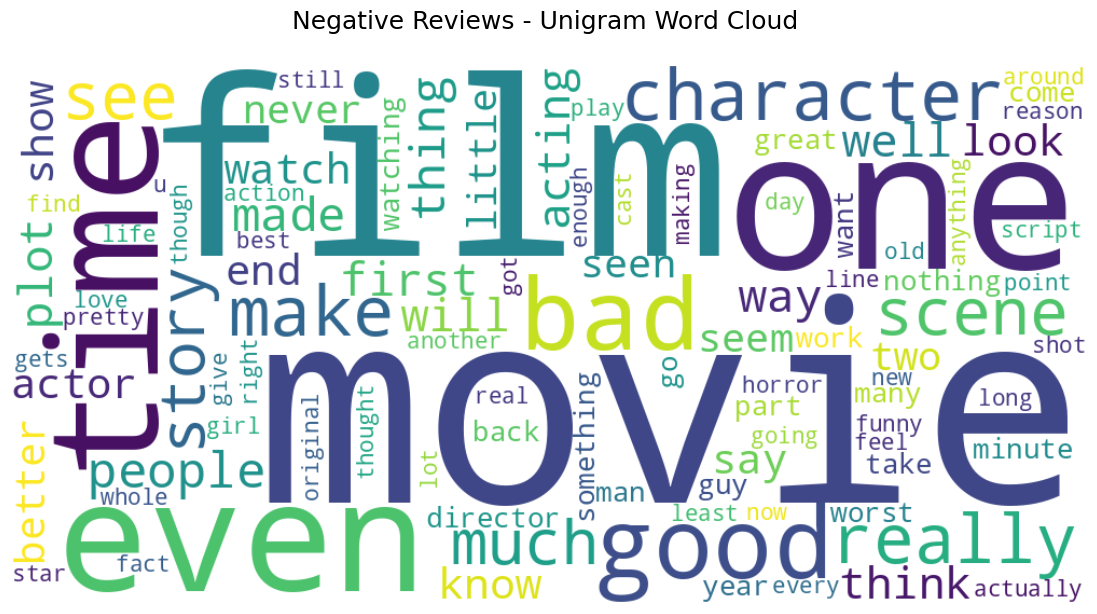

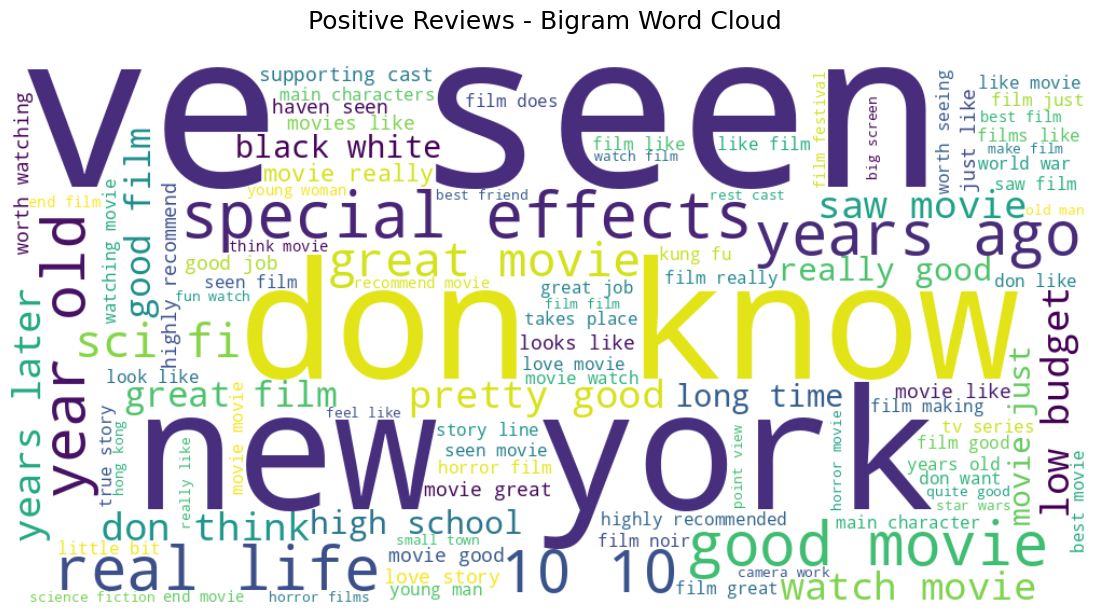

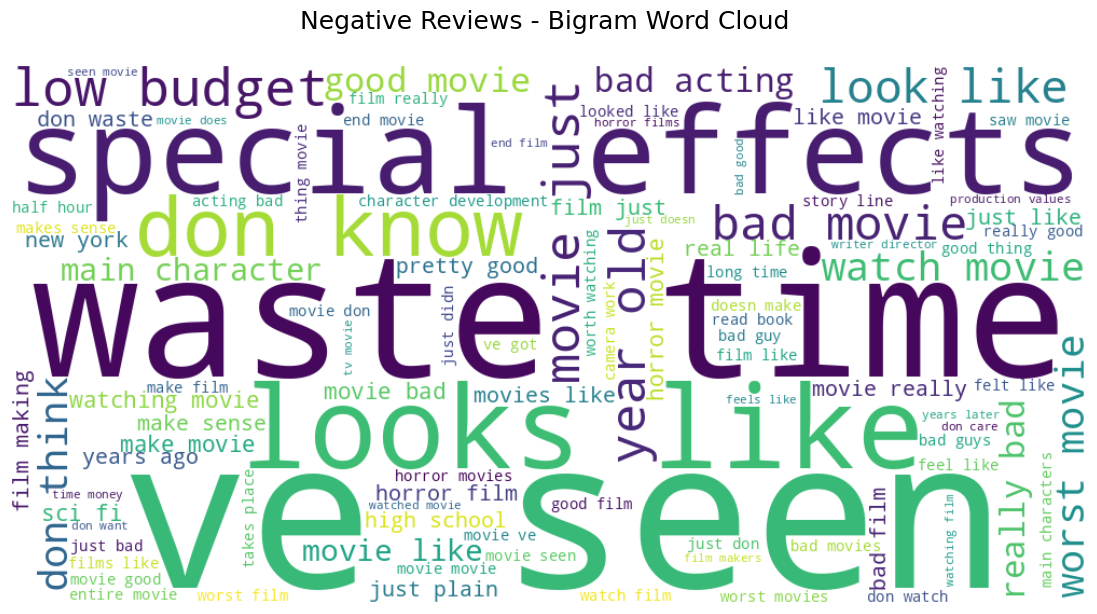

In [20]:
# Import required libraries

from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 1. Separate Positive and Negative Reviews
# ---------------------------------------------------------

positive_reviews = train_df[train_df["label"] == 1]["clean_text"].astype(str)
negative_reviews = train_df[train_df["label"] == 0]["clean_text"].astype(str)


# ---------------------------------------------------------
# 2. Function to Create Unigram Word Cloud
# ---------------------------------------------------------

def create_unigram_wordcloud(reviews, title):

    # Combine all reviews into one large text
    combined_text = " ".join(reviews)

    # Create word cloud
    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        max_words=100,
        collocations=False,
        stopwords=None
    ).generate(combined_text)

    # Display word cloud
    plt.figure(figsize=(14, 7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=18)
    plt.show()


# ---------------------------------------------------------
# 3. Function to Create Bigram Word Cloud
# ---------------------------------------------------------

def create_bigram_wordcloud(reviews, title):

    # Create only two-word combinations
    vectorizer = CountVectorizer(
        ngram_range=(2, 2),
        stop_words="english",
        min_df=2
    )

    # Convert reviews into bigram counts
    bigram_matrix = vectorizer.fit_transform(reviews)

    # Get the bigram names
    bigram_names = vectorizer.get_feature_names_out()

    # Calculate total frequency of every bigram
    bigram_counts = bigram_matrix.sum(axis=0).A1

    # Create dictionary:
    # bigram -> frequency
    bigram_frequency = dict(
        zip(bigram_names, bigram_counts)
    )

    # Generate word cloud using bigram frequencies
    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        max_words=100
    ).generate_from_frequencies(bigram_frequency)

    # Display word cloud
    plt.figure(figsize=(14, 7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=18)
    plt.show()


# =========================================================
# 4. CREATE THE FOUR WORD CLOUDS
# =========================================================


# Cloud 1: Positive Unigrams
create_unigram_wordcloud(
    positive_reviews,
    "Positive Reviews - Unigram Word Cloud \n"
)


# Cloud 2: Negative Unigrams
create_unigram_wordcloud(
    negative_reviews,
    "Negative Reviews - Unigram Word Cloud \n"
)


# Cloud 3: Positive Bigrams
create_bigram_wordcloud(
    positive_reviews,
    "Positive Reviews - Bigram Word Cloud \n"
)


# Cloud 4: Negative Bigrams
create_bigram_wordcloud(
    negative_reviews,
    "Negative Reviews - Bigram Word Cloud \n"
)

## 2.4 Baseline: TF-IDF + Logistic Regression

### What happens to one review?

**Raw review → TF-IDF features → Logistic Regression → Positive / Negative**

A scikit-learn `Pipeline` keeps these steps together.

This helps us apply the **same transformation** during training and prediction.


In [21]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Start with a simple baseline that uses individual words (unigrams).

# A Pipeline connects multiple processing steps together.
logreg_unigram = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        min_df=2,  # df means document frequency.Keep a word only if it appears in at least 2 documents/reviews.
        max_df=0.95,  #Ignore words that appear in more than 95% of documents.
        ngram_range=(1, 1),      # Single words only. These are called unigrams.
        sublinear_tf=True        # Use 1 + log(term frequency)
        # Note - ngram_range=(1, 2) >> contain both unigram and bigrams
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logreg_unigram.fit(train_df["clean_text"], train_df["label"])
print("Model training complete.")


Model training complete.


**Use of sublinear_tf = True**

100 occurrences don't become 100 times as important as one occurrence.

Why?
Imagine this review:
"This movie was bad bad bad bad bad bad bad bad bad bad."

Should "bad" become 10 times more important just because the reviewer repeated it 10 times?
Maybe not.

Sublinear TF reduces the impact of excessive repetition.
More occurrences still matter, but each additional repetition matters a little less.

For intuition:

Frequency     ||   Sublinear value

1        →       1.00

2        →       1.69

10       →       3.30

100      →       5.61


## 2.5 Evaluate the classifier

### What do these metrics tell us?

- **Accuracy:** Out of all predictions, what fraction were correct?
- **Precision:** When the model predicts a class, how often is that prediction correct?
- **Recall:** Out of all actual examples of a class, how many did the model identify?
- **F1:** How can we balance precision and recall?
- **ROC-AUC:** How well do model scores separate/rank positive and negative examples across thresholds?

### Question

**Should we judge a model using only one number? Why or why not?**


In [22]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Predict sentiment for reviews that were not used for training.
y_true = test_df["label"]
y_pred = logreg_unigram.predict(test_df["clean_text"])

# Logistic Regression can also return the probability of each class.
# [:, 1] selects the probability assigned to the positive class.
y_prob = logreg_unigram.predict_proba(test_df["clean_text"])[:, 1]

print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
print("F1       :", round(f1_score(y_true, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_true, y_prob), 4))

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=["negative", "positive"]))


Accuracy : 0.8884
F1       : 0.8885
ROC-AUC  : 0.9559

Classification report:
              precision    recall  f1-score   support

    negative       0.89      0.89      0.89     12500
    positive       0.89      0.89      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



In [23]:
# Build a confusion matrix: rows are actual classes and columns are predicted classes.
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Negative", "Actual Positive"],
    columns=["Predicted Negative", "Predicted Positive"]
)
display(cm_df)


,Predicted Negative,Predicted Positive
Actual Negative,11090,1410
Actual Positive,1381,11119


## 2.6 Mini experiment — Can bigrams help?

Compare the information available to the model:

**Unigrams**

`good`, `not`

**Unigrams + bigrams**

`good`, `not`, `not good`

### Predict before running the code

1. Which representation should understand short phrases better?
2. Will adding bigrams always improve test performance?

Run the experiment and compare the results.


In [24]:
logreg_bigram = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        min_df=2,
        max_df=0.95,
        ngram_range=(1, 2),      # Unigrams + bigrams
        sublinear_tf=True,
        max_features=100000      # Keeps classroom runtime/memory manageable
    )),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_bigram.fit(train_df["clean_text"], train_df["label"])
bigram_pred = logreg_bigram.predict(test_df["clean_text"])
bigram_prob = logreg_bigram.predict_proba(test_df["clean_text"])[:, 1]

print("Bigram Accuracy:", round(accuracy_score(y_true, bigram_pred), 4))
print("Bigram F1      :", round(f1_score(y_true, bigram_pred), 4))
print("Bigram ROC-AUC :", round(roc_auc_score(y_true, bigram_prob), 4))


Bigram Accuracy: 0.8995
Bigram F1      : 0.8999
Bigram ROC-AUC : 0.9628


## 2.7 Compare classical algorithms

So far we have used Logistic Regression.

### Question

**Do we have to use Logistic Regression just because we are using TF-IDF?**

No. Text representation and the learning algorithm are separate choices.

We will compare:

1. Logistic Regression
2. Multinomial Naive Bayes
3. Linear SVM

We will keep the TF-IDF setup broadly similar and change the classifier.

`LinearSVC` does not provide `predict_proba()` by default, so we will use its decision score for ROC-AUC.

* **Logistic Regression:** Learns which words/features push a review toward **positive or negative** sentiment. It combines these signals to estimate which class the review most likely belongs to.

* **Naive Bayes:** Looks at how commonly words occur in each class. For example, if words like *excellent, amazing, loved* occur much more often in positive reviews, it uses that evidence to predict **positive**.

* **Linear SVM:** Tries to find the **best boundary** that separates positive reviews from negative reviews based on their TF-IDF features. It chooses a boundary with as much separation (margin) between the classes as possible.



In [25]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

models = {
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(min_df=2, max_df=0.95, ngram_range=(1, 2),
                                  sublinear_tf=True, max_features=100000)),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(min_df=2, max_df=0.95, ngram_range=(1, 2),
                                  max_features=100000)),
        ("classifier", MultinomialNB())
    ]),
    "Linear SVM": Pipeline([
        ("tfidf", TfidfVectorizer(min_df=2, max_df=0.95, ngram_range=(1, 2),
                                  sublinear_tf=True, max_features=100000)),
        ("classifier", LinearSVC())
    ])
}

results = []
fitted_models = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(train_df["clean_text"], train_df["label"])
    pred = model.predict(test_df["clean_text"])

    # Logistic Regression and Naive Bayes provide probabilities.
    # LinearSVC provides decision_function scores instead.
    if hasattr(model.named_steps["classifier"], "predict_proba"):
        score = model.predict_proba(test_df["clean_text"])[:, 1]
    else:
        score = model.decision_function(test_df["clean_text"])

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, pred),
        "F1": f1_score(y_true, pred),
        "ROC_AUC": roc_auc_score(y_true, score)
    })
    fitted_models[model_name] = model

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
display(results_df.round(4))


Training Logistic Regression...
Training Naive Bayes...
Training Linear SVM...


,Model,Accuracy,F1,ROC_AUC
2,Linear SVM,0.9016,0.9012,0.9654
0,Logistic Regression,0.8995,0.8999,0.9628
1,Naive Bayes,0.8699,0.8661,0.9438


## 2.8 What has Logistic Regression learned?

Positive coefficients push predictions toward **positive sentiment**.

Negative coefficients push predictions toward **negative sentiment**.

### Predict before running the cell

Write down a few words or phrases you expect to appear among:

- Strong positive features
- Strong negative features

Now run the code and compare your expectations with the model.


In [26]:
# Inspect which TF-IDF features the Logistic Regression model associates with sentiment.
lr_model = fitted_models["Logistic Regression"]   #retrieves our trained Logistic Regression pipeline.
vectorizer = lr_model.named_steps["tfidf"]        #give me the trained TF-IDF vectorizer
classifier = lr_model.named_steps["classifier"]   #give me trained classifier

feature_names = np.array(vectorizer.get_feature_names_out())   #give the list of feature/ vocabulary
coefficients = classifier.coef_[0]   #Logistic Regression gives a coefficient/weight to every TF-IDF feature.

# Find features with the strongest negative coefficients
negative_idx = np.argsort(coefficients)[:15]   #np.argsort() sorts the indexes according to coefficient value. Take the top 15

# Find features with the strongest positive coefficients
positive_idx = np.argsort(coefficients)[-15:][::-1]  # [-15:] - takes the 15 largest coefficients. 
                                                     #[::-1] - reverse the order to get max at the top

print("Features strongly associated with NEGATIVE sentiment:")
print(feature_names[negative_idx])

print("\nFeatures strongly associated with POSITIVE sentiment:")
print(feature_names[positive_idx])


Features strongly associated with NEGATIVE sentiment:
['bad' 'worst' 'the worst' 'awful' 'boring' 'poor' 'waste' 'no' 'terrible'
 'nothing' 'worse' 'stupid' 'dull' 'horrible' 'poorly']

Features strongly associated with POSITIVE sentiment:
['great' 'excellent' 'wonderful' 'perfect' 'best' 'the best' 'amazing'
 'love' 'fun' 'loved' 'well' 'today' 'favorite' 'enjoyed' 'beautiful']


## 2.9 Error analysis — Why is the model wrong?

A metric tells us **how often** a model is wrong.

Error analysis helps us understand **why** it is wrong.

### Inspect the misclassified reviews and look for patterns

- Negation — `not bad`
- Mixed sentiment — `great acting, terrible story`
- Sarcasm or irony
- Reviews that change opinion halfway through
- Unusual vocabulary
- Noisy or questionable labels

### Class discussion

For each misclassified review:

1. What did the model predict?
2. What should the prediction have been?
3. Which words may have confused the model?
4. What change could potentially improve the model?


In [27]:
# Use the Logistic Regression model to study incorrect predictions.
lr_pred = lr_model.predict(test_df["clean_text"])
lr_prob = lr_model.predict_proba(test_df["clean_text"])[:, 1]

errors = test_df[["text", "clean_text", "label"]].copy()
errors["prediction"] = lr_pred
errors["positive_probability"] = lr_prob
errors = errors[errors["label"] != errors["prediction"]].copy()

# Calculate how confident the model was in the class it predicted.
errors["prediction_confidence"] = np.where(
    errors["prediction"] == 1,
    errors["positive_probability"],
    1 - errors["positive_probability"]
)

# Start with confidently wrong predictions because they often reveal useful failure patterns.
display(
    errors.sort_values("prediction_confidence", ascending=False)[
        ["text", "label", "prediction", "prediction_confidence"]
    ].head(10)
)


,text,label,prediction,prediction_confidence
4118,This is definitely one of the best Kung fu movies in the history of Cinema. The screenplay is really well done (which is not often the case for this type of movies) and you can see that Chuck (in one of his first role)is a great actor. The final ...,0,1,0.968033
6245,"Mickey Rourke hunts Diane Lane in Elmore Leonard's Killshot It is not like Mickey Rourke ever really disappeared. He has had a steady string of appearances before he burst back on the scene. He was memorable in: Domino, Sin City, Man on Fire, Onc...",0,1,0.963922
3553,"This film has the language, the style and the attitude down ... plus greats rides from Occy (a world champ) and the great Jerry Lopez. John Philbin as Turtle has the surf pidgin down, and the surfing scenes are still the best ever. A true classic...",0,1,0.951599
20621,"This was Laurel and Hardy's last silent film for Roach Studios. However, since the public had a real thirst for ""talkies"", this same short was re-made by the team just a few years later with only a few small plot changes. LAUGHING GRAVY was essen...",1,0,0.938032
12061,"This movie was pure genius. John Waters is brilliant. It is hilarious and I am not sick of it even after seeing it about 20 times since I bought it a few months ago. The acting is great, although Ricki Lake could have been better. And Johnny Depp...",0,1,0.936145
15208,**SPOILERS AHEAD**<br /><br />It is really unfortunate that a movie so well produced turns out to be<br /><br />such a disappointment. I thought this was full of (silly) clichés and<br /><br />that it basically tried to hard. <br /><br />To the (...,1,0,0.935825
5331,"I enjoyed the beautiful scenery in this movie the first time I saw it when I was 9 . Dunderklumpen is kind of cute for kiddies in a corny way. It reminded me of HRPUFFINSTUFF on sat mornings, Its Swedish backdrops make it easy on the eyes . Don't...",0,1,0.934637
11770,"Based on the comments made so far, everyone seems to either hate this movie or love it. I think it would be fair to point out that although this is not a GREAT movie, it has its interesting moments. For one thing, it was filmed on location in Col...",0,1,0.931388
15074,"When the movie first started I thought cheesy. The first ten minutes were really boring. After the slow beginning and some of the soap opera antics, I started liking it. The plot was different than anything I had ever seen. Now, was it a horror? ...",1,0,0.929429
776,"In all honesty, I haven't seen this film for many years, but the few times I have tend to make parts of it stick in my memory, as anyone who has seen it will understand. I first saw it as a child at a YMCA Halloween party in the early Sixties, an...",0,1,0.927453


## 2.10 Challenge the classifier

Create your own difficult movie reviews and see how the model behaves.

Try examples involving:

- Negation
- Mixed sentiment
- Sarcasm
- Strong positive/negative words used in unusual contexts

Can you deliberately make the classifier fail?


In [28]:
custom_reviews = [
    "The acting was fantastic and I loved every minute.",
    "This was a complete waste of two hours.",
    "It was not bad at all.",
    "Great actors, but the story was painfully boring."
]

custom_pred = lr_model.predict(custom_reviews)
custom_prob = lr_model.predict_proba(custom_reviews)[:, 1]

custom_results = pd.DataFrame({
    "review": custom_reviews,
    "prediction": np.where(custom_pred == 1, "positive", "negative"),
    "P(positive)": custom_prob
})
display(custom_results)


,review,prediction,P(positive)
0,The acting was fantastic and I loved every minute.,positive,0.751335
1,This was a complete waste of two hours.,negative,0.041711
2,It was not bad at all.,negative,0.072448
3,"Great actors, but the story was painfully boring.",negative,0.270432


# 3. Named Entity Recognition (NER) — Information Extraction

### Identify the important information

Consider:

> “Satya Nadella met executives from Microsoft in London on Monday.”

Which pieces of text represent:

- A person?
- An organization?
- A location?
- A date/time?

NER identifies useful spans of text and assigns entity labels to them.

### Real-world applications

Imagine processing thousands of:

- News articles
- Emails
- Customer messages
- Financial documents
- Travel messages

Can we automatically extract the people, organizations, locations, dates and money amounts mentioned in them?

A statistical NER model is useful, but its predictions are not guaranteed to be perfect. Domain-specific applications should always be evaluated.


In [29]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 76.9 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [30]:
import spacy

# Load spaCy's small pretrained English pipeline.
# If the model is missing, run: !python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

text = "Satya Nadella met executives from Microsoft in London on Monday."
doc = nlp(text)

entities = []
for ent in doc.ents:
    entities.append({
        "entity": ent.text,
        "label": ent.label_,
        "meaning": spacy.explain(ent.label_)
    })

display(pd.DataFrame(entities))


,entity,label,meaning
0,Satya Nadella,PERSON,"People, including fictional"
1,Microsoft,ORG,"Companies, agencies, institutions, etc."
2,London,GPE,"Countries, cities, states"
3,Monday,DATE,Absolute or relative dates or periods


## 3.1 NER on realistic business sentences

For each sentence below:

1. Identify the entities yourself.
2. Guess the entity type.
3. Run spaCy.
4. Compare your answer with the model.

### Question

**Where did spaCy agree with you, and where did it make a surprising prediction?**


In [31]:
business_examples = [
    "Apple announced a new office in Bengaluru in January 2026.",
    "JPMorgan agreed to invest $500 million in the company.",
    "A passenger flew from New York to London on British Airways last Friday.",
    "Microsoft CEO Satya Nadella spoke at an event in Seattle."
]

print(list(enumerate(business_examples, start=1)))

rows = []
for sentence_id, sentence in enumerate(business_examples, start=1):
    doc = nlp(sentence)
    for ent in doc.ents:
        rows.append({
            "sentence_id": sentence_id,
            "text": sentence,
            "entity": ent.text,
            "label": ent.label_,
            "meaning": spacy.explain(ent.label_)
        })

display(pd.DataFrame(rows))


[(1, 'Apple announced a new office in Bengaluru in January 2026.'), (2, 'JPMorgan agreed to invest $500 million in the company.'), (3, 'A passenger flew from New York to London on British Airways last Friday.'), (4, 'Microsoft CEO Satya Nadella spoke at an event in Seattle.')]


,sentence_id,text,entity,label,meaning
0,1,Apple announced a new office in Bengaluru in January 2026.,Apple,ORG,"Companies, agencies, institutions, etc."
1,1,Apple announced a new office in Bengaluru in January 2026.,Bengaluru,GPE,"Countries, cities, states"
2,1,Apple announced a new office in Bengaluru in January 2026.,January 2026,DATE,Absolute or relative dates or periods
3,2,JPMorgan agreed to invest $500 million in the company.,JPMorgan,ORG,"Companies, agencies, institutions, etc."
4,2,JPMorgan agreed to invest $500 million in the company.,$500 million,MONEY,"Monetary values, including unit"
5,3,A passenger flew from New York to London on British Airways last Friday.,New York,GPE,"Countries, cities, states"
6,3,A passenger flew from New York to London on British Airways last Friday.,London,GPE,"Countries, cities, states"
7,3,A passenger flew from New York to London on British Airways last Friday.,British Airways,ORG,"Companies, agencies, institutions, etc."
8,3,A passenger flew from New York to London on British Airways last Friday.,last Friday,DATE,Absolute or relative dates or periods
9,4,Microsoft CEO Satya Nadella spoke at an event in Seattle.,Microsoft,ORG,"Companies, agencies, institutions, etc."


# 4. Sequence Labeling — NER at token level

### Compare these two problems

**Sentiment classification**

One review → one sentiment label

**Sequence labeling**

A sequence of words → labels attached to individual tokens/spans

### BIO example

| Token | Label |
|---|---|
| Barack | B-PER |
| Obama | I-PER |
| visited | O |
| New | B-LOC |
| York | I-LOC |

- `B` = Beginning of an entity
- `I` = Inside the same entity
- `O` = Outside an entity

### Question

Why is the word `New` difficult to classify without looking at the next word in `New York`?

Context matters. Classical sequence models such as CRFs use information about neighboring words/features and structured labels.

For this session, we will use spaCy for the hands-on NER work and understand CRF at an intuitive level.

**CRF = Conditional Random Field — commonly used for sequence labeling tasks such as Named Entity Recognition (NER).**

# 5. Lab 2 — Topic Modeling with LDA

### Business problem

Imagine receiving more than 18,000 discussion posts.

You do not want to manually read every post.

**Can we automatically discover the major themes being discussed?**

We will use scikit-learn's public **20 Newsgroups** dataset. It contains 18,846 posts across 20 newsgroups.

Although the dataset contains category labels, we will ignore them while training LDA because topic modeling is an **unsupervised** task.

### Core LDA idea - 
##### LDA = Latent Dirichlet Allocation — an unsupervised topic modeling technique used to discover hidden topics/themes in a collection of documents.

- A **document can contain a mixture of topics**.
- A **topic can be represented as a distribution/mixture of words**.

LDA gives us groups of important words. We interpret those words and give the topics meaningful names.


In [32]:
from sklearn.datasets import fetch_20newsgroups

# Remove headers, footers and quoted text so that metadata does not dominate the topics.
news = fetch_20newsgroups(
    subset="all",
    remove=("headers", "footers", "quotes"),
    shuffle=True,
    random_state=42
)

print("Number of documents:", len(news.data))
print("Number of known categories (not used to train LDA):", len(news.target_names))
print("\nExample categories:", news.target_names[:5])


Number of documents: 18846
Number of known categories (not used to train LDA): 20

Example categories: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware']


## 5.1 Read the documents first

Read a few documents before building the topic model.

### Questions

1. What themes can you identify manually?
2. Are the documents clean?
3. What words may create noise?
4. If you had 18,000 documents, could you realistically categorize all of them by hand?

Topic modeling is unsupervised, but understanding the corpus still requires human judgment.


In [33]:
for i in range(3):
    print("=" * 90)
    print(news.data[i][:1200])




I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!


My brother is in the market for a high-performance video card that supports
VESA local bus with 1-2MB RAM.  Does anyone have suggestions/ideas on:

  - Diamond Stealth Pro Local Bus

  - Orchid Farenheit 1280

  - ATI Graphics Ultra Pro

  - Any other high-performance VLB card


Please 

## 5.2 Preprocess for LDA

Preprocessing depends on the NLP task.

For sentiment classification, words such as `not` may be important.

For topic modeling, we mainly want words that help describe the **subject/theme** of a document.

For this lab we will:

1. Convert text into lowercase tokens.
2. Remove punctuation/noise.
3. Remove common stopwords.
4. Remove very short tokens.

We will use a reproducible sample so the exercise runs comfortably during class.


1. Randomly select 6,000 documents from the dataset
2. Clean each document and convert it into a list of useful words for LDA

simple_preprocess: 
This is a convenient Gensim function for basic text preprocessing.It does things such as:
lowercase conversion,
tokenization, and 
punctuation removal

Eg. simple_preprocess("The MOVIE was Amazing!!!")
Output - ['the', 'movie', 'was', 'amazing']

In [34]:
!pip install gensim pyLDAvis

In [35]:

from gensim.utils import simple_preprocess
import numpy as np
from gensim.parsing.preprocessing import STOPWORDS

# Use a reproducible sample so the code runs comfortably during class.
# Increase this number if you want to run the experiment on more documents.
rng = np.random.default_rng(42)
sample_size = min(6000, len(news.data))
sample_idx = rng.choice(len(news.data), size=sample_size, replace=False)
news_docs = [news.data[i] for i in sample_idx]

def preprocess_for_lda(text):
    """Convert a document into useful lowercase tokens for topic modeling."""
    tokens = simple_preprocess(text, deacc=True, min_len=3)
    tokens = [token for token in tokens if token not in STOPWORDS]
    return tokens

processed_docs = [preprocess_for_lda(doc) for doc in news_docs]

print("Original text snippet:", news_docs[0][:500])
print("\nProcessed tokens:", processed_docs[0][:50])


Original text snippet: I've posted a couple of notes about encountering this problem. Based on some 
suggestions from:

Mark Aitchison, University of Canterbury, New Zealand.
	and
Chris A. Larrieu @cs.wm.edu

I think that my problem is a screen saver that also outputs sound (to my 
PC speaker). I'm still looking at some of the other screen savers that I 
use (with a randomizer), but this one definately caused the loss of several 
minutes over night (but not the date this time). 

Processed tokens: ['posted', 'couple', 'notes', 'encountering', 'problem', 'based', 'suggestions', 'mark', 'aitchison', 'university', 'canterbury', 'new', 'zealand', 'chris', 'larrieu', 'edu', 'think', 'problem', 'screen', 'saver', 'outputs', 'sound', 'speaker', 'looking', 'screen', 'savers', 'use', 'randomizer', 'definately', 'caused', 'loss', 'minutes', 'night', 'date', 'time']


## 5.3 Dictionary — convert words to IDs

Suppose our vocabulary contains:

`cat → 0`  
`dog → 1`  
`fish → 2`

A Gensim `Dictionary` creates this consistent **word → ID** mapping for the complete corpus.

### Question

Why might extremely rare words or extremely common words be less useful for discovering topics?

We will filter some of them before training LDA.


The below code takes all the cleaned words from our documents and creates a vocabulary where every unique word gets a unique number/ID.

In [36]:
from gensim.corpora import Dictionary

dictionary = Dictionary(processed_docs)

print("Vocabulary before filtering:", len(dictionary))

# no_below=5: keep a word only if it appears in at least 5 documents
# no_above=0.5: remove words that appear in more than 50% of documents
# keep_n=30000: limit the vocabulary to keep runtime manageable
dictionary.filter_extremes(no_below=5, no_above=0.5, keep_n=30000)

print("Vocabulary after filtering:", len(dictionary))

# Look at a few word → ID mappings
print(list(dictionary.token2id.items())[:20])


Vocabulary before filtering: 49190
Vocabulary after filtering: 10377
[('based', 0), ('caused', 1), ('chris', 2), ('couple', 3), ('date', 4), ('definately', 5), ('edu', 6), ('looking', 7), ('loss', 8), ('mark', 9), ('minutes', 10), ('new', 11), ('night', 12), ('notes', 13), ('outputs', 14), ('posted', 15), ('problem', 16), ('saver', 17), ('screen', 18), ('sound', 19)]


## 5.4 Corpus — Bag-of-Words representation

`doc2bow()` converts a tokenized document into `(word_id, count)` pairs.

Example:

If:

`cat → 0`  
`dog → 1`

then:

`['cat', 'dog', 'cat'] → [(0, 2), (1, 1)]`

### Connection with Day 1

This is the same basic Bag-of-Words idea:

**Which words occur, and how many times do they occur?**


In [37]:
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

print("First processed document tokens:")
print(processed_docs[0][:30])

print("\nFirst document in Bag-of-Words form:")
print(corpus[0][:20])


First processed document tokens:
['posted', 'couple', 'notes', 'encountering', 'problem', 'based', 'suggestions', 'mark', 'aitchison', 'university', 'canterbury', 'new', 'zealand', 'chris', 'larrieu', 'edu', 'think', 'problem', 'screen', 'saver', 'outputs', 'sound', 'speaker', 'looking', 'screen', 'savers', 'use', 'randomizer', 'definately', 'caused']

First document in Bag-of-Words form:
[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 2), (17, 1), (18, 2), (19, 1)]


## 5.5 Train LDA

We will start by asking LDA to discover **10 topics**.

### Important parameters

- `num_topics` — number of latent themes we ask the model to discover
- `passes` — number of full passes through the corpus
- `random_state` — helps us reproduce the experiment

### Question

Does setting `num_topics=10` prove that the corpus really contains exactly 10 meaningful topics?

No. We will later compare different values and inspect both coherence and interpretability.


In [42]:
import gensim
print(gensim.__version__)


4.4.0


In [43]:
from gensim.models import LdaMulticore

lda_model = LdaMulticore(
    corpus=corpus,
    id2word=dictionary,
    num_topics=10,
    random_state=42,
    passes=8,
    iterations=100,
    alpha="asymmetric",
    workers=4
)

## 5.6 Name the topics

Run the model and look only at the top words first.

For example:

`space, nasa, orbit, launch, earth`

### Question

**What would you call this topic?**

Possible interpretation: **Space / Astronomy**

Now do the same for every topic produced by LDA.

There may be mixed or ambiguous topics. That is expected. The topic name is a **human interpretation** of the words produced by the model.


In [44]:
def display_topics(model, num_words=10):    # num_words= how many important words to show per topic
    rows = []
    for topic_id, words in model.show_topics(   #model.show_topics() asks LDA: Show me the topics you discovered.
        num_topics=-1,                          #Show all topics
        num_words=num_words,
        formatted=False                         #Give me the words and their weights as structured Python data rather than one preformatted text string.
    ):
        rows.append({
            "topic_id": topic_id,
            "top_words": ", ".join([word for word, weight in words])
        })
    return pd.DataFrame(rows)

topics_df = display_topics(lda_model, num_words=10)
display(topics_df)


,topic_id,top_words
0,0,"use, edu, space, data, like, available, image, mail, ftp, graphics"
1,1,"like, good, game, think, year, know, drive, new, time, got"
2,2,"know, problem, air, time, edu, think, like, people, windows, car"
3,3,"god, max, jesus, lord, christ, bible, jehovah, father, people, christians"
4,4,"hockey, adl, team, new, league, edu, pit, nhl, san, game"
5,5,"key, encryption, use, chip, clipper, government, security, technology, des, keys"
6,6,"people, like, know, drive, time, said, think, going, armenian, way"
7,7,"armenian, people, turkish, armenians, april, new, government, armenia, state, health"
8,8,"file, output, program, use, bit, com, mac, edu, entry, windows"
9,9,"people, think, like, know, good, believe, right, way, time, point"


## 5.7 Can one document belong to multiple topics?

Consider a news article about:

> Government policy affecting stock markets.

Could the document contain both:

- Politics
- Economics/Finance

LDA represents a document as a **mixture of topic proportions**, rather than forcing every document into exactly one topic.


In [45]:
doc_number = 0
doc_topics = lda_model.get_document_topics(corpus[doc_number], minimum_probability=0.01)

doc_topic_df = pd.DataFrame(doc_topics, columns=["topic_id", "probability"])
doc_topic_df = doc_topic_df.sort_values("probability", ascending=False)

print("Document snippet:")
print(news_docs[doc_number][:800])
print("\nTopic mixture:")
display(doc_topic_df)


Document snippet:
I've posted a couple of notes about encountering this problem. Based on some 
suggestions from:

Mark Aitchison, University of Canterbury, New Zealand.
	and
Chris A. Larrieu @cs.wm.edu

I think that my problem is a screen saver that also outputs sound (to my 
PC speaker). I'm still looking at some of the other screen savers that I 
use (with a randomizer), but this one definately caused the loss of several 
minutes over night (but not the date this time). 

Topic mixture:


,topic_id,probability
0,0,0.973368


## 5.8 Coherence — Do the words in a topic make sense together?

Compare:

**Topic A**

`bank, loan, credit, mortgage, interest`

**Topic B**

`bank, banana, hockey, nasa, recipe`

### Question

Which topic looks more meaningful?

A coherence score gives us a quantitative way to compare how well the important words in topics fit together.

However:

**Coherence is a model-selection aid, not a replacement for human interpretation.**
Coherence measures how well the important words within the discovered topics fit together. Higher coherence generally indicates more interpretable topics, but we should always inspect the topics ourselves as well.

In [46]:
from gensim.models import CoherenceModel

coherence_model = CoherenceModel(
    model=lda_model,
    texts=processed_docs,
    dictionary=dictionary,
    coherence="c_v"
)

coherence_10 = coherence_model.get_coherence()
print("Coherence for 10 topics:", round(coherence_10, 4))


Coherence for 10 topics: 0.5196


## 5.9 Experiment — How many topics should we use?

We will test:

`5, 7, 10, 12, 15`

For every value:

**Number of topics → Train LDA → Calculate coherence → Compare**

### Predict before running

**Will increasing the number of topics always improve coherence and interpretability?**

Run the experiment and examine the result.


In [47]:
topic_numbers = [5, 7, 10, 12, 15]
coherence_results = []
lda_models_by_k = {}

for k in topic_numbers:
    print(f"Training LDA with {k} topics...")

    model_k = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=5,             # Use fewer passes here so that comparing several models takes less time
        iterations=75,
        alpha="auto"
    )

    coherence_k = CoherenceModel(
        model=model_k,
        texts=processed_docs,
        dictionary=dictionary,
        coherence="c_v"
    ).get_coherence()

    coherence_results.append({
        "num_topics": k,
        "coherence": coherence_k
    })
    lda_models_by_k[k] = model_k

coherence_df = pd.DataFrame(coherence_results)
display(coherence_df.round(4))


Training LDA with 5 topics...
Training LDA with 7 topics...
Training LDA with 10 topics...
Training LDA with 12 topics...
Training LDA with 15 topics...


,num_topics,coherence
0,5,0.4866
1,7,0.5082
2,10,0.4929
3,12,0.5608
4,15,0.5692


In [49]:
def display_topics(model, num_words=10):    # num_words= how many important words to show per topic
    rows = []
    for topic_id, words in model.show_topics(   #model.show_topics() asks LDA: Show me the topics you discovered.
        num_topics=-1,                          #Show all topics
        num_words=num_words,
        formatted=False                         #Give me the words and their weights as structured Python data rather than one preformatted text string.
    ):
        rows.append({
            "topic_id": topic_id,
            "top_words": ", ".join([word for word, weight in words])
        })
    return pd.DataFrame(rows)

topics_df = display_topics(lda_models_by_k[15], num_words=10)
display(topics_df)

,topic_id,top_words
0,0,"edu, image, use, available, ftp, mail, window, files, file, data"
1,1,"like, drive, windows, bit, use, mac, dos, card, know, disk"
2,2,"know, edu, msg, problem, soon, food, screen, think, banks, remember"
3,3,"god, jesus, bible, church, christian, believe, christ, christians, lord, faith"
4,4,"appears, art, adl, man, new, wolverine, black, rider, slip, gerard"
5,5,"key, encryption, chip, clipper, use, des, security, keys, data, government"
6,6,"people, like, time, gun, fbi, government, evidence, know, batf, way"
7,7,"law, israel, state, jewish, people, jews, israeli, arab, homosexuality, sex"
8,8,"max, file, output, entry, program, use, section, line, null, entries"
9,9,"people, think, like, know, good, right, time, way, want, point"


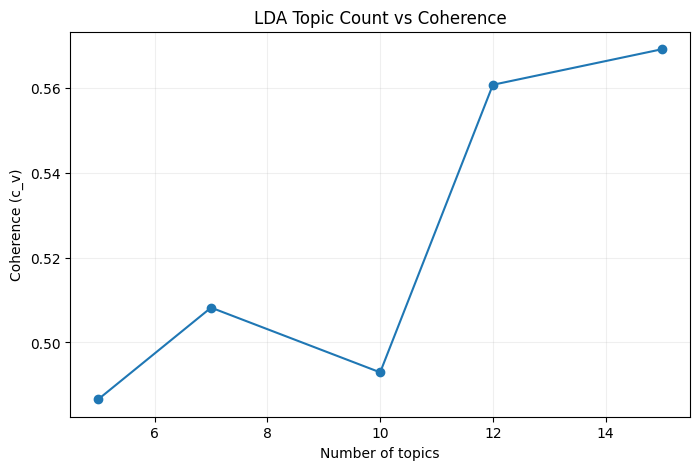

In [50]:
# Plot the number of topics against coherence.
# Compare the score with the actual topic words before deciding which topic count is useful.
plt.figure(figsize=(8, 5))
plt.plot(coherence_df["num_topics"], coherence_df["coherence"], marker="o")
plt.xlabel("Number of topics")
plt.ylabel("Coherence (c_v)")
plt.title("LDA Topic Count vs Coherence")
plt.grid(alpha=0.2)
plt.show()


## 5.10 Optional visualization with pyLDAvis

`pyLDAvis` helps us visually explore:

- Topic prevalence
- Topic overlap
- Important words within topics

This section is optional because package compatibility can vary across notebook environments.


In [ ]:
# Optional: run this section if pyLDAvis is installed in your environment.
# import pyLDAvis
# import pyLDAvis.gensim_models as gensimvis
#
# vis = gensimvis.prepare(lda_model, corpus, dictionary)
# pyLDAvis.display(vis)


# 6. Language Modeling — Bridge to modern NLP

### Complete the sentence

> “The customer was very ____.”

What words could reasonably come next?

Humans use context to predict plausible continuations. Language models learn patterns that help assign probabilities to sequences/tokens or predict tokens from context.

### Historical progression

**n-grams → RNN/LSTM → Transformers → modern LLMs**

### Question

How is this different from sentiment classification?

- Sentiment classification predicts a **label for the text**.
- Language modeling learns/predicts the **language sequence itself**.


# 7. In-class Assignment — Airline Customer Feedback

## Business scenario

You are part of an airline Customer Experience analytics team.

Thousands of customers discuss flights on social media. The business wants to understand:

1. **How do customers feel?**
2. **Which useful entities are customers mentioning?**
3. **What recurring problems or service themes are customers discussing?**

Use the public **Twitter US Airline Sentiment** dataset. Common versions contain tweet text, airline name and three sentiment classes: **positive, neutral and negative**.

### Q1 — 3-class sentiment classifier [10 marks]

Build a classifier that predicts `positive`, `neutral`, or `negative`.

- Inspect the class distribution.
- Split train/test using stratification.
- Generate TF-IDF features.
- Train Logistic Regression.
- Report **precision, recall and F1 for each class** and macro-F1.
- Inspect at least 5 misclassified tweets.

### Q2 — NER on 20 random tweets [10 marks]

- Randomly select 20 tweets.
- Run spaCy NER.
- Create a table with `tweet`, `entity`, `entity_type`.
- Identify which extracted entities could be useful to an airline and explain why.

### Q3 — LDA with 5 topics [10 marks]

- Preprocess tweet text for topic modeling.
- Build a Gensim Dictionary and Corpus.
- Train LDA with `num_topics=5`.
- Print the top 10 words for each topic.
- Give each topic a meaningful business name.
- Justify each topic name using the top words.


## 7.1 Assignment starter — Load the airline dataset

After downloading the public dataset, load `Tweets.csv`.

Common versions contain columns such as:

- `text`
- `airline_sentiment`

Inspect the data before starting the three questions.


In [51]:
# Load the public airline dataset after downloading it locally:
airline_df = pd.read_csv("/kaggle/input/datasets/shashwathk15/tweets/Tweets.csv")

# Keep the two fields required for the assignment.
airline_df = airline_df[["text", "airline_sentiment"]].dropna().copy()
#
display(airline_df.head())
print(airline_df["airline_sentiment"].value_counts())


,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials to the experience... tacky.,positive
2,@VirginAmerica I didn't today... Must mean I need to take another trip!,neutral
3,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",negative
4,@VirginAmerica and it's a really big bad thing about it,negative


airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


--- Class Distribution (Proportions) ---
airline_sentiment
negative    62.691257
neutral     21.168033
positive    16.140710
Name: proportion, dtype: float64


--- Classification Report ---
              precision    recall  f1-score   support

    negative       0.81      0.93      0.87      1835
     neutral       0.64      0.49      0.55       620
    positive       0.82      0.58      0.68       473

    accuracy                           0.78      2928
   macro avg       0.75      0.67      0.70      2928
weighted avg       0.77      0.78      0.77      2928



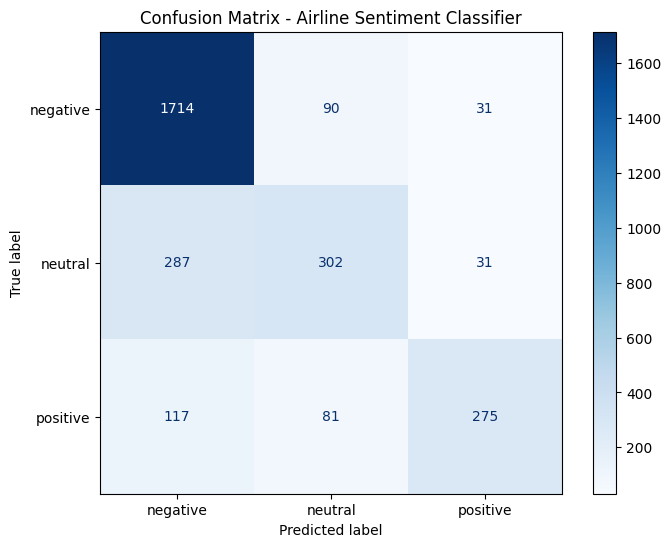


--- Inspecting First 5 Misclassified Tweets (Total: 637) ---

Tweet Text: @united past
True Sentiment: neutral | Predicted Sentiment: negative
------------------------------------------------------------
Tweet Text: @JetBlue would you say a delay is more likely? Thanks so much.
True Sentiment: positive | Predicted Sentiment: negative
------------------------------------------------------------
Tweet Text: @united This link in your tweet goes to someone's internal email -&gt; http://t.co/ZksX79itdN...... Probably one of your 3rd party IT contracts
True Sentiment: neutral | Predicted Sentiment: negative
------------------------------------------------------------
Tweet Text: @united of course but they were just as helpless as everyone else .
True Sentiment: negative | Predicted Sentiment: neutral
------------------------------------------------------------
Tweet Text: @USAirways Well I did miss it. But gate agents had rebooked boarding pass waiting when I landed. Time for lunch &amp; a 

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Step 1: Inspect Class Distribution ---
print("--- Class Distribution (Proportions) ---")
print(airline_df["airline_sentiment"].value_counts(normalize=True) * 100)
print("\n" + "="*50 + "\n")

# --- Step 2: Stratified Train/Test Split ---
X = airline_df["text"]
y = airline_df["airline_sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Ensures proportional representation of all classes in train and test
)

# --- Step 3: Feature Extraction (TF-IDF) ---
# Initialize the TF-IDF vectorizer (removing English stop words to reduce noise)
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

# Fit and transform the training data, then transform the test data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# --- Step 4: Train Logistic Regression Classifier ---
lr_classifier = LogisticRegression(max_iter=1000, random_state=42)
lr_classifier.fit(X_train_tfidf, y_train)

# --- Step 5: Evaluate Performance (Precision, Recall, F1, Macro-F1) ---
y_pred = lr_classifier.predict(X_test_tfidf)

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# --- Step 6: Confusion Matrix Visualization ---
cm = confusion_matrix(y_test, y_pred, labels=lr_classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_classifier.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Airline Sentiment Classifier")
plt.show()

# --- Step 7: Inspect at least 5 Misclassified Tweets ---
# Combine test texts, true labels, and predictions into a DataFrame
results_df = pd.DataFrame({
    'text': X_test,
    'true_sentiment': y_test,
    'predicted_sentiment': y_pred
})

# Filter out rows where predictions do not match the true labels
misclassified_df = results_df[results_df['true_sentiment'] != results_df['predicted_sentiment']]

print(f"\n--- Inspecting First 5 Misclassified Tweets (Total: {len(misclassified_df)}) ---\n")
for idx, row in misclassified_df.head(5).iterrows():
    print(f"Tweet Text: {row['text']}")
    print(f"True Sentiment: {row['true_sentiment']} | Predicted Sentiment: {row['predicted_sentiment']}")
    print("-" * 60)

In [53]:
macro_f1=f1_score(y_test,y_pred,average='macro')
print(macro_f1)

0.6996031081044577


In [54]:
import spacy
import pandas as pd

# Load spaCy's English language model (ensure you've run: python -m spacy download en_core_web_sm)
nlp = spacy.load("en_core_web_sm")

# --- Step 1: Randomly select 20 tweets ---
# Using sample() with a fixed random_state ensures reproducibility
sample_tweets = airline_df["text"].sample(n=20, random_state=42).tolist()

# --- Step 2: Run spaCy NER and build the extraction list ---
extracted_data = []

for tweet in sample_tweets:
    doc = nlp(tweet)
    if doc.ents:
        for ent in doc.ents:
            extracted_data.append({
                "tweet": tweet,
                "entity": ent.text,
                "entity_type": ent.label_
            })
    else:
        # Optional: Track tweets with no entities if needed
        pass

# --- Step 3: Create a DataFrame Table ---
ner_df = pd.DataFrame(extracted_data)

# Display the table cleanly
pd.set_option('display.max_colwidth', None)
print(f"--- Extracted Entities from 20 Random Tweets (Total Entities Found: {len(ner_df)}) ---")
display(ner_df)

--- Extracted Entities from 20 Random Tweets (Total Entities Found: 29) ---


,tweet,entity,entity_type
0,@SouthwestAir you're my early frontrunner for best airline! #oscars2016,oscars2016,PERSON
1,@USAirways how is it that my flt to EWR was Cancelled Flightled yet flts to NYC from USAirways are still flying?,EWR,ORG
2,@USAirways how is it that my flt to EWR was Cancelled Flightled yet flts to NYC from USAirways are still flying?,NYC,LOC
3,@USAirways how is it that my flt to EWR was Cancelled Flightled yet flts to NYC from USAirways are still flying?,USAirways,ORG
4,@JetBlue what is going on with your BDL to DCA flights yesterday and today?! Why is every single one getting delayed?,BDL,ORG
5,@JetBlue what is going on with your BDL to DCA flights yesterday and today?! Why is every single one getting delayed?,DCA,ORG
6,@JetBlue what is going on with your BDL to DCA flights yesterday and today?! Why is every single one getting delayed?,yesterday,DATE
7,@JetBlue what is going on with your BDL to DCA flights yesterday and today?! Why is every single one getting delayed?,today,DATE
8,"@JetBlue do they have to depart from Washington, D.C.??",Washington,GPE
9,"@JetBlue do they have to depart from Washington, D.C.??",D.C.,GPE


In [55]:
import gensim
from gensim.utils import simple_preprocess
from gensim.corpora import Dictionary
import nltk
from nltk.corpus import stopwords

# Ensure stopwords are available
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Add domain-specific stop words that dominate airline tweets without adding distinct topic value
stop_words.update(['flight', 'flights', 'airline', 'airlines', 'get', 'got', 'im', 'dont', 'cant', 'u', 'ur'])

def preprocess_text(text):
    # simple_preprocess lowercases and tokenizes text, removing punctuation
    tokens = simple_preprocess(text, deacc=True)
    # Remove stopwords and very short words
    return [word for word in tokens if word not in stop_words and len(word) > 2]

# Apply preprocessing across the entire dataset text column
processed_docs = [preprocess_text(text) for text in airline_df["text"]]

# Build Gensim Dictionary
dictionary = Dictionary(processed_docs)

# Filter out extremes to reduce noise (words appearing in < 5 documents or > 50% of documents)
dictionary.filter_extremes(no_below=5, no_above=0.5)

# Convert processed documents into a Bag-of-Words (BoW) corpus
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

print(f"Total unique tokens in dictionary: {len(dictionary)}")
print(f"Total documents in corpus: {len(corpus)}")

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Total unique tokens in dictionary: 2699
Total documents in corpus: 14640


In [64]:
from gensim.models import LdaModel

# Train LDA model with num_topics = 8
lda_model_8 = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=8,
    random_state=42,
    passes=10,
    iterations=100,
    chunksize=100,
    eval_every=None
)

# Define 8 comprehensive business names for each topic
topic_business_names_8 = {
    0: "Customer Service Wait Times & Phone Support",
    1: "Flight Delays & Schedule Disruption",
    2: "Cancellations & Emergency Rebooking",
    3: "Baggage & Luggage Handling Complaints",
    4: "Frequent Flyer Status & Loyalty Points",
    5: "In-Flight Cabin Experience & Crew Service",
    6: "Ticketing, Extra Fees & Refund Claims",
    7: "Airport Check-in, Boarding & Gate Chaos"
}

# Print top 10 words for each of the 8 topics
print("--- 8-Topic LDA Modeling Results ---")
for idx, topic in lda_model_8.print_topics(num_topics=8, num_words=10):
    print(f"\n[Topic {idx}] Business Name: {topic_business_names_8[idx]}")
    print(f"Top Words: {topic}")

--- 8-Topic LDA Modeling Results ---

[Topic 0] Business Name: Customer Service Wait Times & Phone Support
Top Words: 0.052*"weather" + 0.049*"waiting" + 0.049*"wait" + 0.042*"airport" + 0.032*"email" + 0.028*"response" + 0.027*"days" + 0.025*"stuck" + 0.025*"made" + 0.023*"dallas"

[Topic 1] Business Name: Flight Delays & Schedule Disruption
Top Words: 0.048*"back" + 0.036*"dfw" + 0.030*"plane" + 0.028*"hrs" + 0.027*"guys" + 0.027*"thank" + 0.021*"going" + 0.018*"told" + 0.017*"want" + 0.017*"today"

[Topic 2] Business Name: Cancellations & Emergency Rebooking
Top Words: 0.056*"http" + 0.053*"time" + 0.037*"another" + 0.036*"new" + 0.035*"check" + 0.033*"customers" + 0.028*"yes" + 0.025*"info" + 0.022*"also" + 0.022*"website"

[Topic 3] Business Name: Baggage & Luggage Handling Complaints
Top Words: 0.048*"one" + 0.035*"late" + 0.032*"hour" + 0.026*"know" + 0.023*"rebooked" + 0.021*"really" + 0.021*"make" + 0.021*"people" + 0.020*"let" + 0.017*"lax"

[Topic 4] Business Name: Frequent 

In [65]:
from gensim.models.coherencemodel import CoherenceModel

# --- 1. Print Corpus and Dictionary Statistics ---
print("--- Corpus & Vocabulary Statistics ---")
print(f"Total Documents in Corpus: {len(corpus)}")
print(f"Total Unique Tokens in Dictionary (Vocabulary Size): {len(dictionary)}")

# Calculate total word count across the corpus
total_words_in_corpus = sum(freq for doc in corpus for _, freq in doc)
print(f"Total Token Instances (Word Count) in Corpus: {total_words_in_corpus}")

# --- 2. Compute Coherence Score (C_v) ---
# Coherence model measures how semantically interpretable the words are to humans
coherence_model_lda = CoherenceModel(
    model=lda_model, 
    texts=processed_docs, 
    dictionary=dictionary, 
    coherence='c_v'
)

coherence_lda = coherence_model_lda.get_coherence()
print(f"\n--- Model Evaluation ---")
print(f"LDA Topic Coherence Score (C_v): {coherence_lda:.4f}")

--- Corpus & Vocabulary Statistics ---
Total Documents in Corpus: 14640
Total Unique Tokens in Dictionary (Vocabulary Size): 2699
Total Token Instances (Word Count) in Corpus: 118141

--- Model Evaluation ---
LDA Topic Coherence Score (C_v): 0.2682


# 9. Rapid-fire recap

Answer each question before checking your notes.

1. Why can't Logistic Regression directly understand raw text?
2. What does TF-IDF contribute to the pipeline?
3. Why can removing `not` hurt sentiment classification?
4. What extra information can bigrams capture?
5. Why do we need a held-out test set?
6. Why can accuracy be insufficient?
7. What does F1 balance?
8. What is the difference between classification and NER?
9. Why is NER considered sequence labeling?
10. What do `B`, `I`, and `O` mean?
11. Is LDA supervised or unsupervised?
12. Does LDA automatically give a business-friendly topic name?
13. What are a Gensim Dictionary and Corpus?
14. What does coherence try to measure?
15. Why shouldn't we select the number of topics using only one score?
16. How is language modeling different from sentiment classification?

### Closing mental map

**Classification:** one/few labels for a document → sentiment / spam / intent  
**NER / sequence labeling:** labels over token spans → people / organizations / locations  
**Topic modeling:** discover latent themes → LDA  
**Language modeling:** model/predict language sequences → bridge to modern LLMs
